In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/drive/MyDrive/feature_engineered_real_estate.csv')
df.head()

,TotalFinishedArea,LivingUnits,TotalAppraisedValue,SaleYear,SaleMonth,PriceRatio,AssrLandUse_APT FOUR,AssrLandUse_CONDOMINIMUM,AssrLandUse_MULTI DWLG,AssrLandUse_ONE FAMILY,AssrLandUse_THREE FAMILY,AssrLandUse_TWO FAMILY
0,1092.0,1.0,187200,2024,7,1.383547,False,False,False,True,False,False
1,936.0,1.0,192300,2022,4,1.081643,False,False,False,True,False,False
2,1111.0,1.0,148400,2023,12,0.842318,False,False,False,True,False,False
3,1684.0,1.0,197900,2021,1,0.894391,False,False,False,True,False,False
4,900.0,1.0,170700,2021,9,1.101347,False,False,False,True,False,False


# Step 1

In [2]:
# Check data
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(3137, 12)
Index(['TotalFinishedArea', 'LivingUnits', 'TotalAppraisedValue', 'SaleYear',
       'SaleMonth', 'PriceRatio', 'AssrLandUse_APT FOUR',
       'AssrLandUse_CONDOMINIMUM', 'AssrLandUse_MULTI DWLG',
       'AssrLandUse_ONE FAMILY', 'AssrLandUse_THREE FAMILY',
       'AssrLandUse_TWO FAMILY'],
      dtype='object')
TotalFinishedArea           0
LivingUnits                 0
TotalAppraisedValue         0
SaleYear                    0
SaleMonth                   0
PriceRatio                  0
AssrLandUse_APT FOUR        0
AssrLandUse_CONDOMINIMUM    0
AssrLandUse_MULTI DWLG      0
AssrLandUse_ONE FAMILY      0
AssrLandUse_THREE FAMILY    0
AssrLandUse_TWO FAMILY      0
dtype: int64


In [3]:
# Define response and predictors
y_col = "PriceRatio"

x_cols = [
    "TotalFinishedArea",
    "LivingUnits",
    "TotalAppraisedValue",
    "SaleYear",
    "SaleMonth",
    "AssrLandUse_APT FOUR",
    "AssrLandUse_CONDOMINIMUM",
    "AssrLandUse_MULTI DWLG",
    "AssrLandUse_THREE FAMILY",
    "AssrLandUse_TWO FAMILY"
]

In [4]:
# Split into training and test sets
df_train, df_test = train_test_split(df, test_size=0.2, random_state=6243)

print(df_train.shape)
print(df_test.shape)

(2509, 12)
(628, 12)


In [5]:
# Standardize only the continuous predictors
cont_cols = [
    "TotalFinishedArea",
    "LivingUnits",
    "TotalAppraisedValue",
    "SaleYear",
    "SaleMonth"
]

scaler = StandardScaler()

df_train = df_train.copy()
df_test = df_test.copy()

df_train[cont_cols] = scaler.fit_transform(df_train[cont_cols])
df_test[cont_cols] = scaler.transform(df_test[cont_cols])

df_train.head()

,TotalFinishedArea,LivingUnits,TotalAppraisedValue,SaleYear,SaleMonth,PriceRatio,AssrLandUse_APT FOUR,AssrLandUse_CONDOMINIMUM,AssrLandUse_MULTI DWLG,AssrLandUse_ONE FAMILY,AssrLandUse_THREE FAMILY,AssrLandUse_TWO FAMILY
625,0.987019,0.338207,0.647918,-0.012819,0.670056,0.788397,False,False,False,False,False,True
2623,1.197209,1.494284,0.447504,-0.882083,0.956213,1.022044,False,False,False,False,True,False
211,-1.160396,-0.817871,-1.449198,-0.012819,0.670056,1.122914,False,False,False,True,False,False
2552,0.374654,0.338207,-0.030803,-0.882083,-0.474571,0.669291,False,False,False,False,False,True
1687,-1.122330,-0.817871,-1.241552,-0.012819,-0.188414,0.988372,False,True,False,False,False,False


# Step 2

In [6]:
with pm.Model() as bayes_model:
    # Priors
    intercept = pm.StudentT("Intercept", nu=4, mu=0, sigma=10)

    w_TotalFinishedArea   = pm.Normal("w_TotalFinishedArea", mu=0, sigma=10)
    w_LivingUnits         = pm.Normal("w_LivingUnits", mu=0, sigma=10)
    w_TotalAppraisedValue = pm.Normal("w_TotalAppraisedValue", mu=0, sigma=10)
    w_SaleYear            = pm.Normal("w_SaleYear", mu=0, sigma=10)
    w_SaleMonth           = pm.Normal("w_SaleMonth", mu=0, sigma=10)

    w_APT_FOUR            = pm.Normal("w_APT_FOUR", mu=0, sigma=10)
    w_CONDOMINIMUM        = pm.Normal("w_CONDOMINIMUM", mu=0, sigma=10)
    w_MULTI_DWLG          = pm.Normal("w_MULTI_DWLG", mu=0, sigma=10)
    w_THREE_FAMILY        = pm.Normal("w_THREE_FAMILY", mu=0, sigma=10)
    w_TWO_FAMILY          = pm.Normal("w_TWO_FAMILY", mu=0, sigma=10)

    sigma = pm.HalfNormal("sigma", sigma=1)

    # Linear predictor
    mu = (
        intercept
        + w_TotalFinishedArea   * df_train["TotalFinishedArea"]
        + w_LivingUnits         * df_train["LivingUnits"]
        + w_TotalAppraisedValue * df_train["TotalAppraisedValue"]
        + w_SaleYear            * df_train["SaleYear"]
        + w_SaleMonth           * df_train["SaleMonth"]
        + w_APT_FOUR            * df_train["AssrLandUse_APT FOUR"]
        + w_CONDOMINIMUM        * df_train["AssrLandUse_CONDOMINIMUM"]
        + w_MULTI_DWLG          * df_train["AssrLandUse_MULTI DWLG"]
        + w_THREE_FAMILY        * df_train["AssrLandUse_THREE FAMILY"]
        + w_TWO_FAMILY          * df_train["AssrLandUse_TWO FAMILY"]
    )

    # Likelihood
    y_obs = pm.Normal("PriceRatio", mu=mu, sigma=sigma, observed=df_train[y_col])

    # Posterior sampling
    trace_bayes = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        random_seed=6243,
        target_accept=0.9,
        return_inferencedata=True
    )

Output()

# Step 3

In [7]:
# Posterior summaries

# Summary table
summary = az.summary(trace_bayes, round_to=4)
print(summary)

                         mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
Intercept              1.1177  0.0279  1.0681   1.1702     0.0011   0.0010   
sigma                  0.2052  0.0030  0.1997   0.2109     0.0001   0.0001   
w_APT_FOUR            -0.0493  0.1225 -0.2807   0.1780     0.0045   0.0038   
w_CONDOMINIMUM         0.0248  0.0130 -0.0014   0.0478     0.0003   0.0003   
w_LivingUnits          0.0646  0.0327  0.0060   0.1274     0.0013   0.0011   
w_MULTI_DWLG          -0.1101  0.1194 -0.3334   0.1084     0.0031   0.0026   
w_SaleMonth            0.0172  0.0044  0.0089   0.0248     0.0001   0.0001   
w_SaleYear             0.0869  0.0043  0.0790   0.0949     0.0001   0.0001   
w_THREE_FAMILY        -0.0903  0.0780 -0.2353   0.0531     0.0030   0.0028   
w_TWO_FAMILY          -0.0625  0.0404 -0.1337   0.0146     0.0016   0.0014   
w_TotalAppraisedValue  0.0040  0.0077 -0.0107   0.0183     0.0002   0.0002   
w_TotalFinishedArea   -0.0286  0.0106 -0.0488  -0.0082     0.000

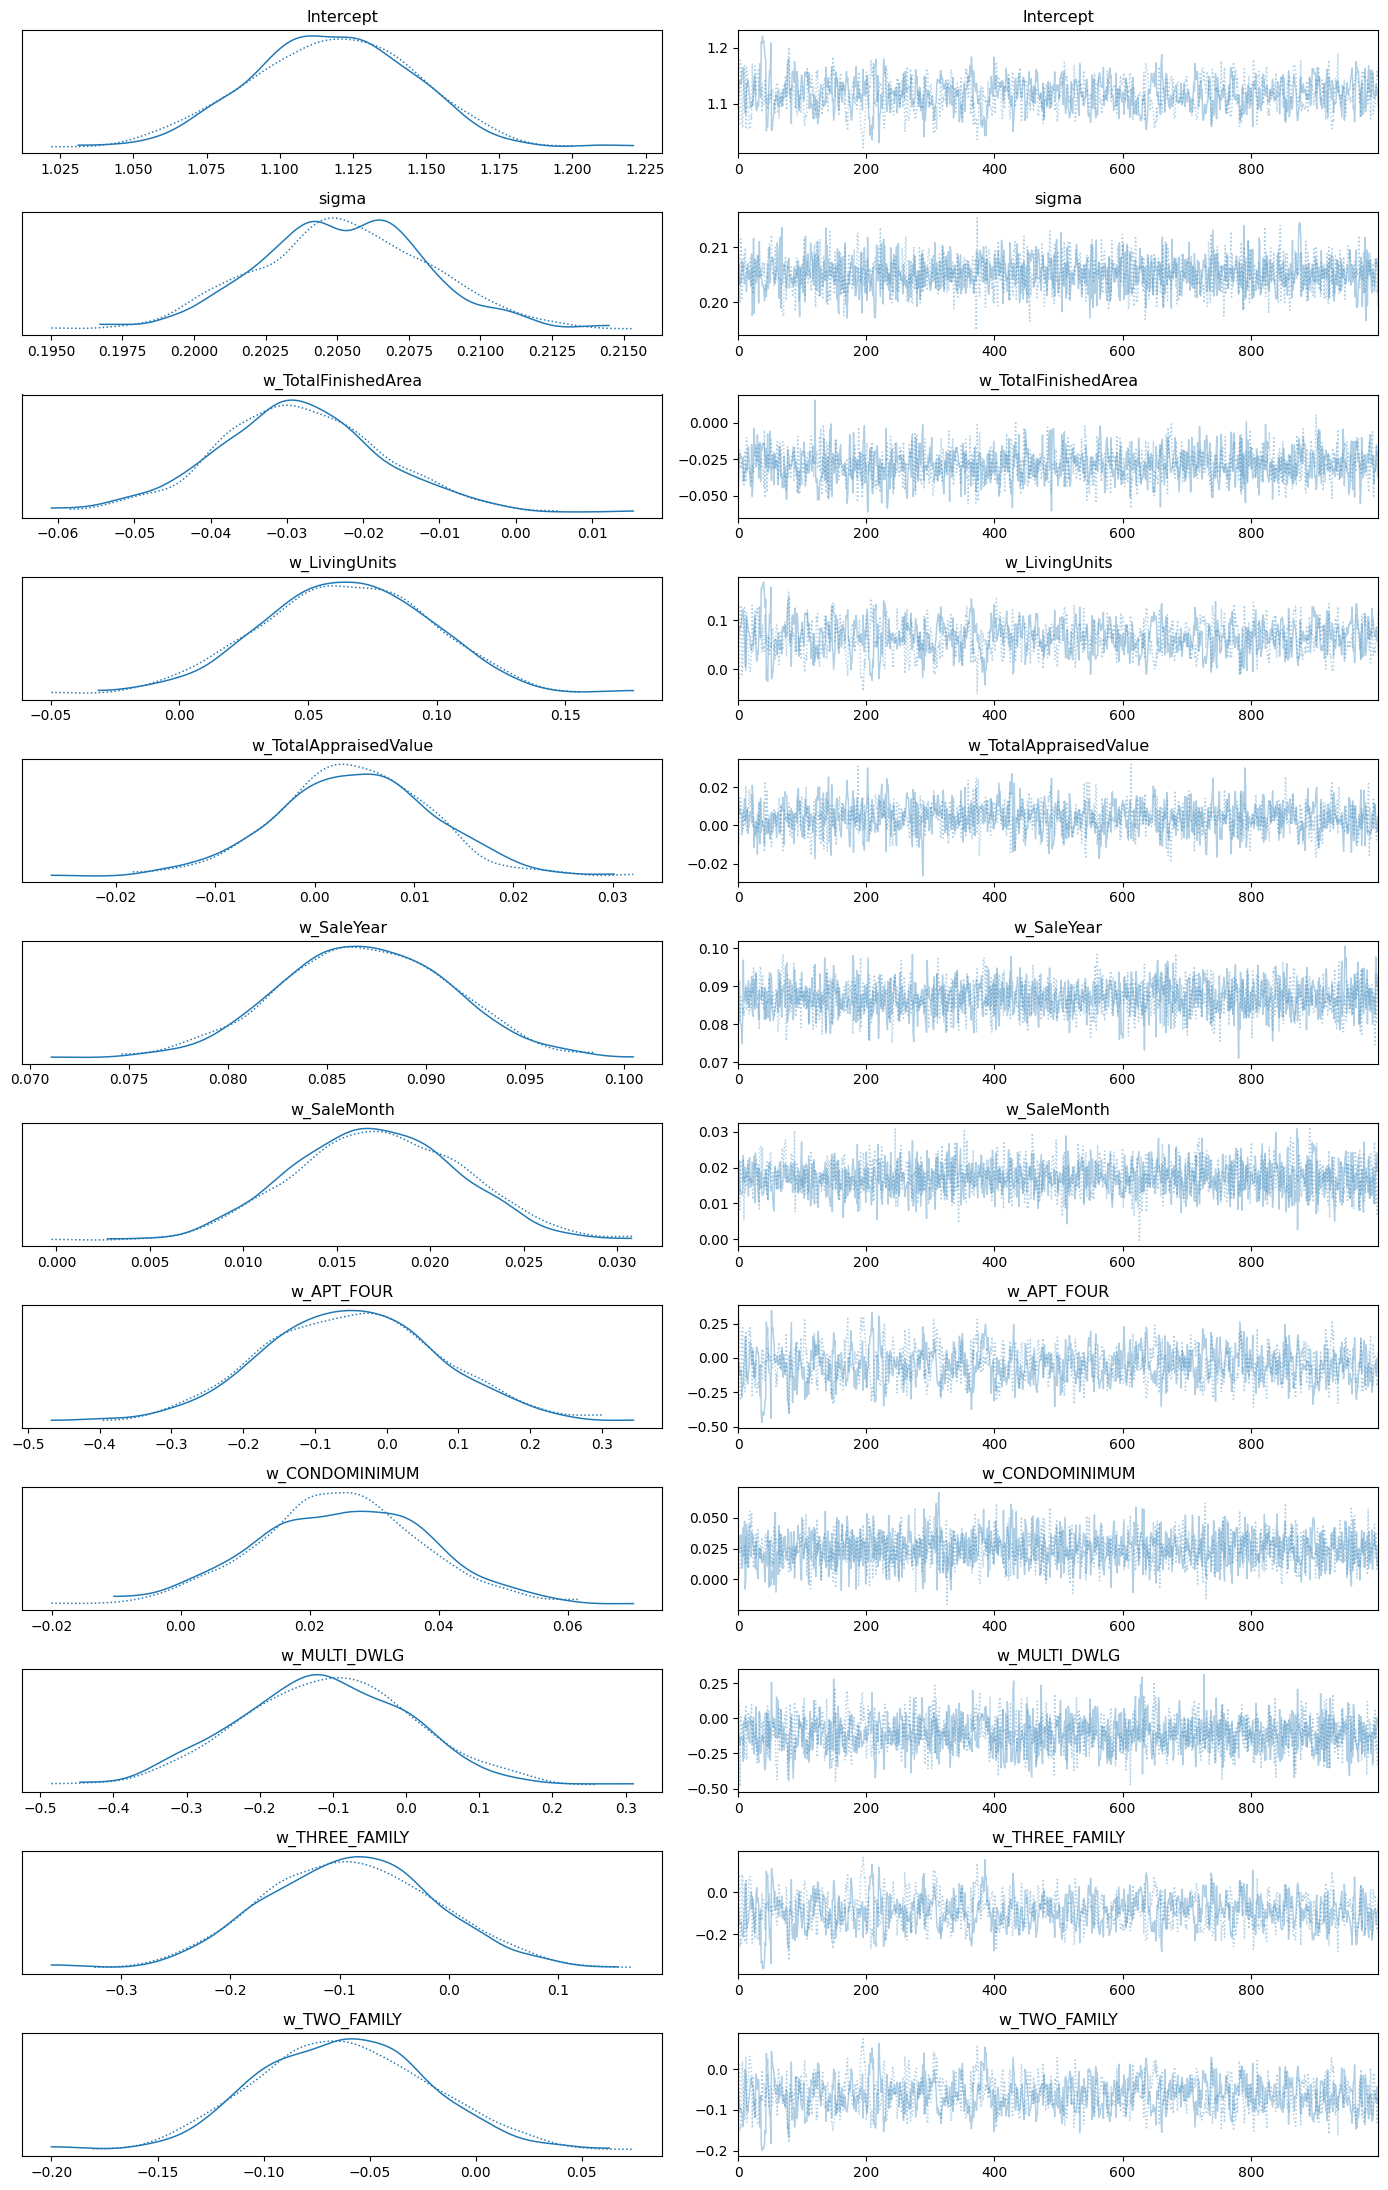

In [8]:
az.plot_trace(
    trace_bayes,
    var_names=[
        "Intercept", "sigma",
        "w_TotalFinishedArea", "w_LivingUnits", "w_TotalAppraisedValue",
        "w_SaleYear", "w_SaleMonth",
        "w_APT_FOUR", "w_CONDOMINIMUM", "w_MULTI_DWLG",
        "w_THREE_FAMILY", "w_TWO_FAMILY"
    ],
    figsize=(14, 22)
)
plt.tight_layout()
plt.show()